# Fig 4.15, 4.16, 4.17
Oscillatory networks.
## Figure 4.15 (A)

In [1]:
using OrdinaryDiffEq
using ModelingToolkit
using Plots
Plots.default(linewidth=2)

The model

In [2]:
@independent_variables t
@variables A(t) B(t)
@parameters k0 k1 k2 n
D = Differential(t)

eqs = [
    D(A) ~ k0 - k1 * A * (1 + B^n),
    D(B) ~ k1 * A * (1 + B^n) - k2 * B
]

@mtkbuild osys = ODESystem(eqs, t)

Model osys:
Equations (2):
  2 standard: see equations(osys)
Unknowns (2): see unknowns(osys)
  A(t)
  B(t)
Parameters (4): see parameters(osys)
  k0
  k2
  k1
  n

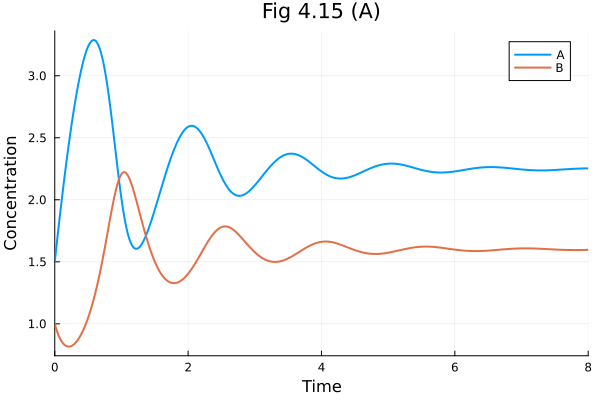

In [3]:
tend = 8.0
ps1 = Dict(k0 => 8, k1 => 1, k2 => 5, n => 2)
prob = ODEProblem(osys, [A => 1.5, B => 1.0], tend, ps1)
u0s = [
    [1.5, 1.0],
    [0.0, 1.0],
    [0.0, 3.0],
    [2.0, 0.0],
]

sols = map(u0s) do u0
    solve(remake(prob, u0=u0))
end

plot(sols[1], xlabel="Time", ylabel="Concentration", title ="Fig 4.15 (A)", xlims=(0, 8))

## Fig 4.15 (B)

In [4]:
∂F415 = function (x, y; scale=20)
    da, db = prob.f([x, y], prob.p, nothing)
    s = sqrt(hypot(da, db)) * scale
    return (da / s, db / s)
end

∂A415 = (x, y) -> prob.f([x, y], prob.p, nothing)[1]
∂B415 = (x, y) -> prob.f([x, y], prob.p, nothing)[2]

#8 (generic function with 1 method)

Grid points

In [5]:
r = range(0, 4, 21)
xx = [x for y in r, x in r]
yy = [y for y in r, x in r];

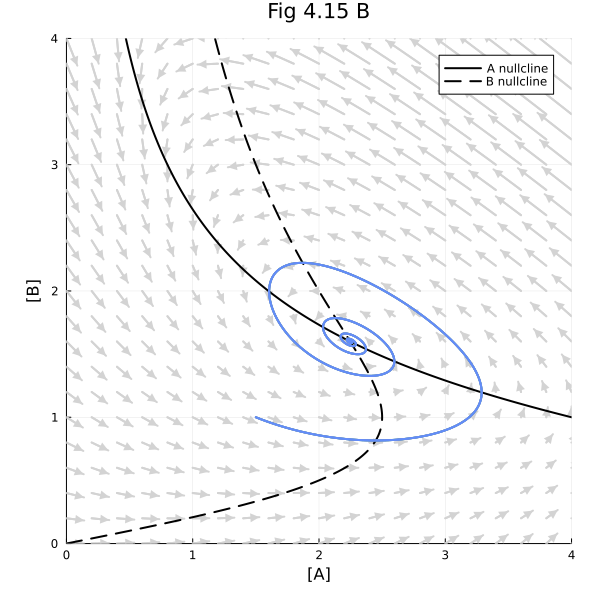

In [6]:
fig = plot(title="Fig 4.15 B")
quiver!(fig, xx, yy, quiver=∂F415, line=(:lightgrey), arrow=(:closed), aspect_ratio=:equal)
contour!(fig, 0:0.01:4, 0:0.01:4, ∂A415, levels=[0], cbar=false, line=(:black))
plot!(fig, Float64[], Float64[], line=(:black), label="A nullcline")
contour!(fig, 0:0.01:4, 0:0.01:4, ∂B415, levels=[0], cbar=false, line=(:black, :dash))
plot!(fig, Float64[], Float64[], line=(:black, :dash), label="B nullcline")
for sol in sols
    plot!(fig, sol, idxs=(A, B), label=nothing)
end
plot!(fig, xlim=(0, 4), ylim=(0, 4), legend=:topright, size=(600, 600), xlabel="[A]", ylabel="[B]")

## Fig 4.16 A

Oscillatory parameter set

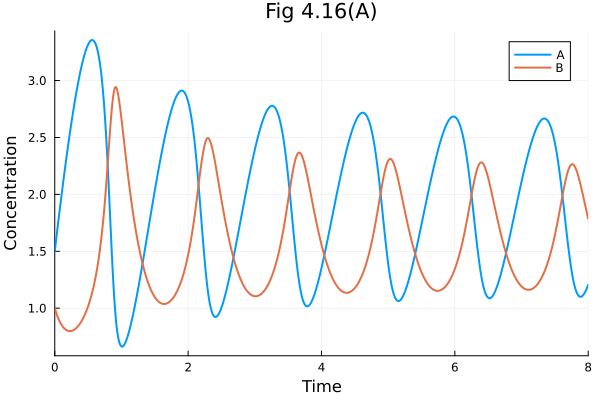

In [7]:
ps2 = Dict(k0 => 8, k1 => 1, k2 => 5, n => 2.5)
tend = 100.0
u0s = [
    [1.5, 1.0],
    [0.0, 1.0],
    [0.0, 3.0],
    [2.0, 0.0],
]

prob416 = remake(prob, p=ps2)

sols = map(u0s) do u0
    solve(remake(prob416, u0=u0))
end

plot(sols[1], xlabel="Time", ylabel="Concentration", title ="Fig 4.16(A)", xlims=(0, 8))

## Fig 4.16 b

In [8]:
∂F416 = function (x, y; scale=20)
    da, db = prob416.f([x, y], prob416.p, nothing)
    s = sqrt(hypot(da, db)) * scale
    return (da / s, db / s)
end
∂A416 = (x, y) -> prob416.f([x, y], prob416.p, nothing)[1]
∂B416 = (x, y) -> prob416.f([x, y], prob416.p, nothing)[2]

#21 (generic function with 1 method)

In [9]:
r = range(0, 4, 21)
xx = [x for y in r, x in r]
yy = [y for y in r, x in r];

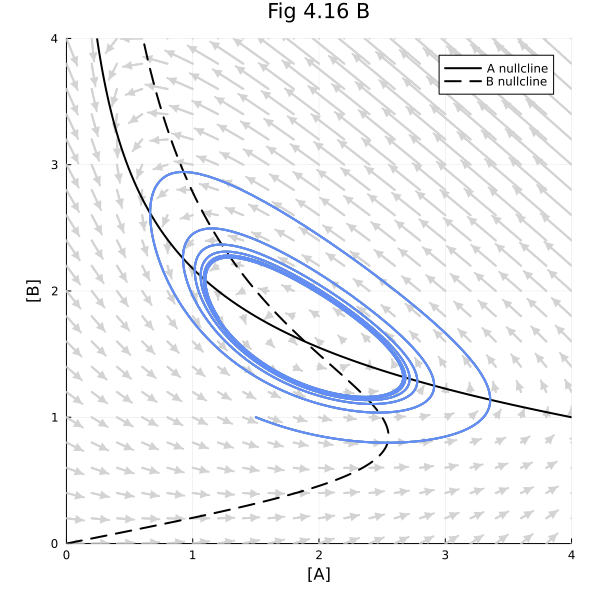

In [10]:
fig = plot(title="Fig 4.16 B")
quiver!(fig, xx, yy, quiver=∂F416, line=(:lightgrey), arrow=(:closed), aspect_ratio=:equal)
contour!(fig, 0:0.01:4, 0:0.01:4, ∂A416, levels=[0], cbar=false, line=(:black))
plot!(fig, Float64[], Float64[], line=(:black), label="A nullcline")
contour!(fig, 0:0.01:4, 0:0.01:4, ∂B416, levels=[0], cbar=false, line=(:black, :dash))
plot!(fig, Float64[], Float64[], line=(:black, :dash), label="B nullcline")
for sol in sols
    plot!(fig, sol, idxs=(A, B), label=nothing)
end
plot!(fig, xlim=(0, 4), ylim=(0, 4), legend=:topright, size=(600, 600), xlabel="[A]", ylabel="[B]")

## Fig 4.17

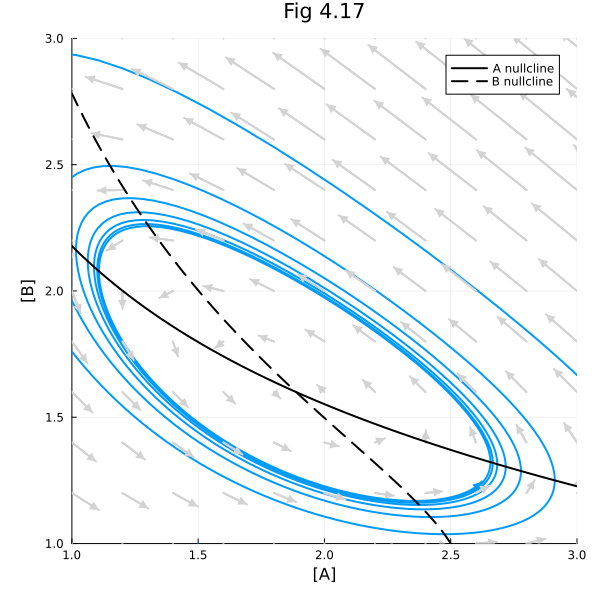

In [11]:
prob417 = remake(prob, p=ps2, u0=[2.0, 1.5], tspan=10.0)
sol = solve(prob417)

fig = plot(title="Fig 4.17")
plot!(fig, sol, idxs=(A, B), label=nothing, arrow=:closed)
quiver!(fig, xx, yy, quiver=∂F416, line=(:lightgrey), arrow=(:closed), aspect_ratio=:equal)
contour!(fig, 1:0.01:3, 1:0.01:3, ∂A416, levels=[0], cbar=false, line=(:black))
plot!(fig, identity, 0, 0, line=(:black), label="A nullcline")
contour!(fig, 1:0.01:3, 1:0.01:3, ∂B416, levels=[0], cbar=false, line=(:black, :dash))
plot!(fig, identity, 0, 0, line=(:black, :dash), label="B nullcline")
plot!(fig, xlims=(1, 3), ylims=(1, 3), legend=:topright, size=(600, 600), xlabel="[A]", ylabel="[B]")

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*